In [1]:
import sys

import torch

import pandas as pd

import pm4py
from pm4py.visualization.petri_net import visualizer as pn_vis

from config.feature_config import FeatureConfig
from config.ga_config import GAConfig

from utils.general_utils import set_stdout_to_file, set_seed
from utils.feature_utils import df_to_sequence_array

from model.preprocessor import PreprocessorArtifacts

from model.next_event_model import ProcessLSTM
from model.model_wrapper import ModelWrapper

from ga_search.search import CounterfactualGA

from process.engine import ProcessModelConstraintEngine
from process.experimenter import ExperimentHandler

### --- Load Dataset & Models ---

In [2]:
set_seed(seed=42)

In [3]:
df = pd.read_excel(
    "../../data/bpic17.xlsx",
    engine="openpyxl",
    keep_default_na=False,
    dtype={
        "case:concept:name": "string",
        "concept:name": "string",
        "lifecycle:transition": "string",
        "org:resource": "string",
        "case:LoanGoal": "string",
        "case:ApplicationType": "string",
        "Accepted": "string",
        "Selected": "string",
        "case:RequestedAmount": "float32",
        "FirstWithdrawalAmount": "float32",
        "NumberOfTerms": "float32",
        "MonthlyCost": "float32",
        "CreditScore": "float32",
        "OfferedAmount": "float32",
        "time_delta": "float32",
    }
)

df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])

In [4]:
df.head(20)

,case:concept:name,time:timestamp,Accepted,CreditScore,FirstWithdrawalAmount,MonthlyCost,NumberOfTerms,OfferedAmount,Selected,case:ApplicationType,case:LoanGoal,case:RequestedAmount,concept:name,lifecycle:transition,org:resource,time_delta
0,Application_1000086665,2016-08-03 15:57:21.673,NA,0.0,0.0,0.000000,0.0,0.0,NA,New credit,"Other, see explanation",5000.0,A_Create Application,complete,User_1,0.000000e+00
1,Application_1000086665,2016-08-03 15:57:21.734,NA,0.0,0.0,0.000000,0.0,0.0,NA,New credit,"Other, see explanation",5000.0,A_Submitted,complete,User_1,6.100000e-02
2,Application_1000086665,2016-08-03 15:58:28.299,NA,0.0,0.0,0.000000,0.0,0.0,NA,New credit,"Other, see explanation",5000.0,A_Concept,complete,User_1,6.656500e+01
3,Application_1000086665,2016-08-05 13:57:07.419,NA,0.0,0.0,0.000000,0.0,0.0,NA,New credit,"Other, see explanation",5000.0,A_Accepted,complete,User_5,1.655191e+05
4,Application_1000086665,2016-08-05 13:59:57.320,True,0.0,5000.0,241.279999,22.0,5000.0,False,New credit,"Other, see explanation",5000.0,O_Create Offer,complete,User_5,1.699010e+02
5,Application_1000086665,2016-08-05 13:59:58.162,NA,0.0,0.0,0.000000,0.0,0.0,NA,New credit,"Other, see explanation",5000.0,O_Created,complete,User_5,8.420000e-01
6,Application_1000086665,2016-08-05 14:01:23.264,NA,0.0,0.0,0.000000,0.0,0.0,NA,New credit,"Other, see explanation",5000.0,O_Sent (mail and online),complete,User_5,8.510200e+01
7,Application_1000086665,2016-08-05 14:01:23.288,NA,0.0,0.0,0.000000,0.0,0.0,NA,New credit,"Other, see explanation",5000.0,A_Complete,complete,User_5,2.400000e-02
8,Application_1000086665,2016-09-05 06:00:36.710,NA,0.0,0.0,0.000000,0.0,0.0,NA,New credit,"Other, see explanation",5000.0,A_Cancelled,complete,User_1,2.649554e+06
9,Application_1000086665,2016-09-05 06:00:36.829,NA,0.0,0.0,0.000000,0.0,0.0,NA,New credit,"Other, see explanation",5000.0,O_Cancelled,complete,User_1,1.190000e-01


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
feature_config = FeatureConfig.load()

In [7]:
feature_config.summary()

  activity_feature:    concept:name
  feature_order:       ['Accepted', 'CreditScore', 'FirstWithdrawalAmount', 'MonthlyCost', 'NumberOfTerms', 'OfferedAmount', 'Selected', 'case:ApplicationType', 'case:LoanGoal', 'case:RequestedAmount', 'concept:name', 'lifecycle:transition', 'org:resource', 'time_delta']
--------------------------------------------------------------------------------------------------------------------------------------
Feature                        Type           Level    Vary   Range/Categories                         MAD        Source              
--------------------------------------------------------------------------------------------------------------------------------------
case:LoanGoal                  categorical    case     yes    ['Boat', 'Business goal', 'Car', ...]    N/A        data_derived        
case:ApplicationType           categorical    case     yes    ['Limit raise', 'New credit']            N/A        data_derived        
Accepted         

In [8]:
preprocessor_artifacts = PreprocessorArtifacts.load()

In [9]:
model = ProcessLSTM.load()

In [10]:
model_wrapper = ModelWrapper(
    model=model,
    preprocessor_artifacts=preprocessor_artifacts,
    device=device
)

### --- Process Constraints ---

In [11]:
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(
    df,
    noise_threshold=0.5,
    case_id_key='case:concept:name',  
    activity_key='concept:name',
    timestamp_key='time:timestamp'
)

engine = ProcessModelConstraintEngine(
    petri_net=net,
    initial_marking=initial_marking,
    final_marking=final_marking
)
engine.save()

In [12]:
# engine = ProcessModelConstraintEngine.load()

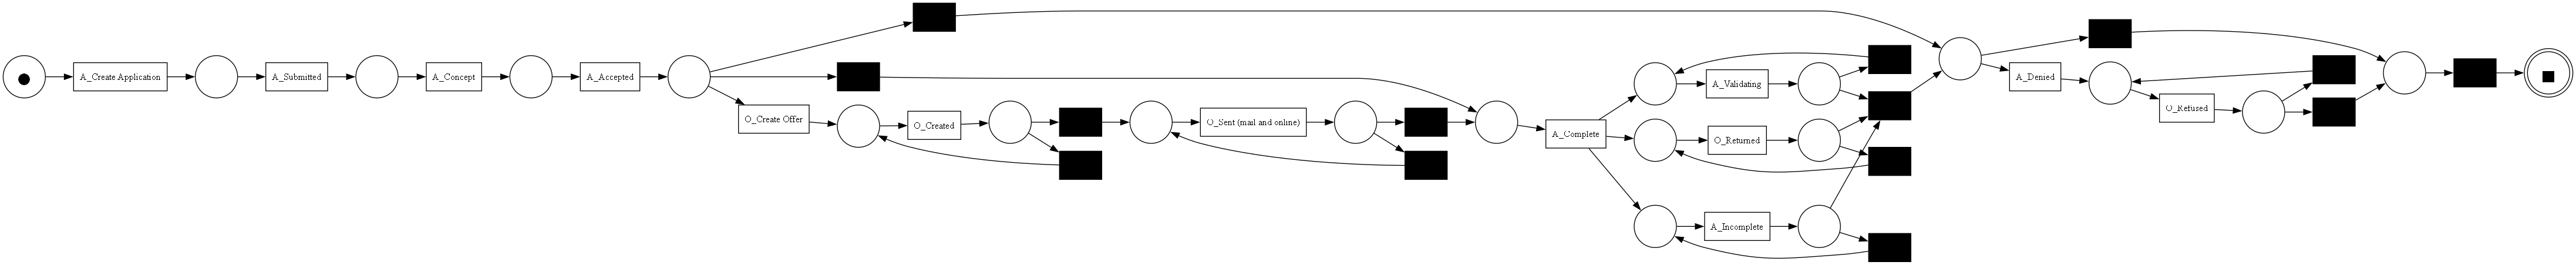

In [13]:
gviz = pn_vis.apply(
    net,
    initial_marking,
    final_marking,
)

pn_vis.view(gviz)

In [14]:
engine.parallel_sets

[{'A_Incomplete', 'A_Validating', 'O_Returned'}]

In [15]:
engine.branching_sets

[{'A_Complete',
  'A_Incomplete',
  'A_Validating',
  'O_Create Offer',
  'O_Created',
  'O_Returned',
  'O_Sent (mail and online)'},
 {'O_Create Offer', 'O_Created', 'O_Sent (mail and online)'},
 {'A_Denied', 'O_Refused'}]

### --- Experiments Generation ---

In [16]:
log_file, original_stdout = set_stdout_to_file(filepath="logs/bpic17-cf_generated_experiments_ga_output.txt", console=False)

In [17]:
generator = ExperimentHandler(
    constraint_engine=engine,
)

In [18]:
exp_df_sin = generator.generate_experiments_from_log(
    df=df,
    case_id_field="case:concept:name",
    activity_field="concept:name",
    sort_field="time:timestamp",
    save_path="experiments/cf_generated_experiments_single_desired",
    min_desired=1,
    max_desired=1,
)

In [19]:
exp_df_mul = generator.generate_experiments_from_log(
    df=df,
    case_id_field="case:concept:name",
    activity_field="concept:name",
    sort_field="time:timestamp",
    save_path="experiments/cf_generated_experiments_multiple_desired",
    min_desired=2,
)

In [20]:
max(exp_df_sin['num_desired'])

1

In [21]:
len(exp_df_sin)

500

In [22]:
exp_df_sin.head()

,template_id,case:concept:name,trace_length,start_pos,length,num_desired,source_pattern,target_pattern,desired_positions,source_support,target_support,num_cases_for_template,experiment_type
0,0,Application_509718181,7,3,3,1,"(O_Create Offer, O_Created, O_Sent (mail and o...","(O_Create Offer, O_Created, O_Create Offer)",{5: {'O_Create Offer'}},9851,776,10,window_variant_mixed
1,0,Application_1424170205,9,3,3,1,"(O_Create Offer, O_Created, O_Sent (mail and o...","(O_Create Offer, O_Created, O_Create Offer)",{5: {'O_Create Offer'}},9851,776,10,window_variant_mixed
2,0,Application_542586744,10,3,3,1,"(O_Create Offer, O_Created, O_Sent (mail and o...","(O_Create Offer, O_Created, O_Create Offer)",{5: {'O_Create Offer'}},9851,776,10,window_variant_mixed
3,0,Application_1690291723,11,3,3,1,"(O_Create Offer, O_Created, O_Sent (mail and o...","(O_Create Offer, O_Created, O_Create Offer)",{5: {'O_Create Offer'}},9851,776,10,window_variant_mixed
4,0,Application_135180486,12,3,3,1,"(O_Create Offer, O_Created, O_Sent (mail and o...","(O_Create Offer, O_Created, O_Create Offer)",{5: {'O_Create Offer'}},9851,776,10,window_variant_mixed


In [23]:
min(exp_df_mul['num_desired'])

2

In [24]:
max(exp_df_mul['num_desired'])

9

In [25]:
len(exp_df_mul)

500

In [26]:
exp_df_mul.head()

,template_id,case:concept:name,trace_length,start_pos,length,num_desired,source_pattern,target_pattern,desired_positions,source_support,target_support,num_cases_for_template,experiment_type
0,0,Application_1589000981,8,0,3,2,"(A_Create Application, A_Submitted, A_Concept)","(A_Create Application, A_Concept, A_Accepted)","{1: {'A_Concept'}, 2: {'A_Accepted'}}",20423,11086,10,window_variant_mixed
1,0,Application_1367573970,10,0,3,2,"(A_Create Application, A_Submitted, A_Concept)","(A_Create Application, A_Concept, A_Accepted)","{1: {'A_Concept'}, 2: {'A_Accepted'}}",20423,11086,10,window_variant_mixed
2,0,Application_707684890,11,0,3,2,"(A_Create Application, A_Submitted, A_Concept)","(A_Create Application, A_Concept, A_Accepted)","{1: {'A_Concept'}, 2: {'A_Accepted'}}",20423,11086,10,window_variant_mixed
3,0,Application_111867995,12,0,3,2,"(A_Create Application, A_Submitted, A_Concept)","(A_Create Application, A_Concept, A_Accepted)","{1: {'A_Concept'}, 2: {'A_Accepted'}}",20423,11086,10,window_variant_mixed
4,0,Application_82157828,13,0,3,2,"(A_Create Application, A_Submitted, A_Concept)","(A_Create Application, A_Concept, A_Accepted)","{1: {'A_Concept'}, 2: {'A_Accepted'}}",20423,11086,10,window_variant_mixed


In [27]:
# exp_df_sin, metadata_sin = ExperimentHandler.load("experiments/cf_generated_experiments_single_desired")
# print("Mined using parameters:", metadata_sin["parameters"])

# exp_df_mul, metadata_mul = ExperimentHandler.load("experiments/cf_generated_experiments_multiple_desired")
# print("Mined using parameters:", metadata_mul["parameters"])

### --- Counterfactuals ---

In [28]:
ga_config = GAConfig(
    w_distance=1.0,
    w_sparsity=1.0,
    w_margin=1.0,
    w_process_violation=1.0,
)
ga_config.validate()

cf_GA = CounterfactualGA(
    ga_config=ga_config,
    feature_config=feature_config,
    model_wrapper=model_wrapper
)

In [29]:
results_sin = generator.run_experiment_df(
    cf_method=cf_GA,
    technique="GA_single_desired",
    exp_df=exp_df_sin,
    df=df,
    feature_config=feature_config,
    case_id_field="case:concept:name",
    sort_field="time:timestamp",
)

Experiments:   0%|          | 0/500 [00:00<?, ?case/s]

In [30]:
results_sin

,template_id,case:concept:name,trace_length,num_desired,num_flexible,DISTANCE,CONT_DISTANCE,CAT_DISTANCE,SPARSITY,PROCESS_VIOLATION,...,best_cf_fitness,best_cf_process_violation,best_cf_distance,best_cf_cat_distance,best_cf_cont_distance,best_cf_sparsity,best_cf_margin_loss,best_cf_margin_loss_na,best_cf_margin_loss_flipped,best_cf_margin_loss_na_flipped
0,0,Application_509718181,7,1,0,0.449604,0.322737,0.576471,0.570833,0.117647,...,0.783800,0.117647,0.311986,0.470588,0.153384,0.354167,0.0,0.000000,0.0,0.0
1,0,Application_1424170205,9,1,0,0.437602,0.286969,0.588235,0.587500,0.285714,...,0.769429,0.285714,0.192048,0.294118,0.089978,0.291667,0.0,0.000000,0.0,0.0
2,0,Application_542586744,10,1,3,0.460391,0.279605,0.641176,0.617708,0.347826,...,0.940920,0.347826,0.259760,0.352941,0.166579,0.333333,0.0,0.000000,0.0,0.0
3,0,Application_1690291723,11,1,2,0.247068,0.129429,0.364706,0.290625,0.840000,...,1.045325,0.840000,0.101159,0.176471,0.025847,0.104167,0.0,0.963410,0.0,1.0
4,0,Application_135180486,12,1,3,0.295346,0.240692,0.350000,0.397917,0.827778,...,1.066744,0.444444,0.247299,0.235294,0.259305,0.375000,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,48,Application_317628520,22,1,8,0.317531,0.195062,0.440000,0.414216,0.619149,...,0.674854,0.617021,0.028421,0.028571,0.028270,0.029412,0.0,0.962927,0.0,1.0
375,48,Application_2144131288,23,1,5,0.287215,0.164430,0.410000,0.356863,0.640816,...,0.835987,0.632653,0.105295,0.171429,0.039161,0.098039,0.0,0.936932,0.0,1.0
376,48,Application_2057503198,24,1,6,0.383594,0.242903,0.524286,0.528431,0.484314,...,0.840285,0.470588,0.154011,0.228571,0.079450,0.215686,0.0,0.000000,0.0,0.0
377,48,Application_727907012,25,1,3,0.447240,0.277337,0.617143,0.602451,0.238679,...,0.646783,0.000000,0.284038,0.371429,0.196647,0.362745,0.0,0.000000,0.0,0.0


In [31]:
results_mul = generator.run_experiment_df(
    cf_method=cf_GA,
    technique="GA_multiple_desired",
    exp_df=exp_df_mul,
    df=df,
    feature_config=feature_config,
    case_id_field="case:concept:name",
    sort_field="time:timestamp",
)

Experiments:   0%|          | 0/500 [00:00<?, ?case/s]

In [32]:
results_mul

,template_id,case:concept:name,trace_length,num_desired,num_flexible,DISTANCE,CONT_DISTANCE,CAT_DISTANCE,SPARSITY,PROCESS_VIOLATION,...,best_cf_fitness,best_cf_process_violation,best_cf_distance,best_cf_cat_distance,best_cf_cont_distance,best_cf_sparsity,best_cf_margin_loss,best_cf_margin_loss_na,best_cf_margin_loss_flipped,best_cf_margin_loss_na_flipped
0,0,Application_1589000981,8,2,0,0.366004,0.212009,0.520000,0.404167,0.363636,...,0.546970,0.363636,0.100000,0.200000,0.000000,0.083333,0.0,0.487931,0.0,0.500
1,0,Application_1367573970,10,2,0,0.349779,0.209558,0.490000,0.387500,0.461538,...,0.644872,0.461538,0.100000,0.200000,0.000000,0.083333,0.0,0.489746,0.0,0.500
2,0,Application_707684890,11,2,0,0.347477,0.254953,0.440000,0.433333,0.500000,...,0.791345,0.500000,0.124678,0.200000,0.049356,0.166667,0.0,0.477004,0.0,0.500
3,0,Application_111867995,12,2,2,0.313173,0.226346,0.400000,0.412500,0.533333,...,0.800366,0.533333,0.100366,0.200000,0.000732,0.166667,0.0,0.490387,0.0,0.500
4,0,Application_82157828,13,2,3,0.337318,0.224637,0.450000,0.375000,0.562500,...,0.745833,0.562500,0.100000,0.200000,0.000000,0.083333,0.0,0.490363,0.0,0.500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,48,Application_1049158506,13,8,4,0.272523,0.155761,0.389286,0.315385,0.720000,...,1.070626,0.720000,0.171139,0.214286,0.127991,0.179487,0.0,0.861578,0.0,0.875
379,48,Application_151062598,13,8,4,0.296086,0.195743,0.396429,0.339744,0.695000,...,0.813961,0.600000,0.111397,0.142857,0.079937,0.102564,0.0,0.984515,0.0,1.000
380,48,Application_1205404110,13,8,4,0.354265,0.244244,0.464286,0.417949,0.720000,...,1.033021,0.720000,0.159175,0.214286,0.104064,0.153846,0.0,0.859332,0.0,0.875
381,48,Application_1167485975,13,8,4,0.373190,0.242808,0.503571,0.453846,0.720000,...,1.006549,0.720000,0.132703,0.214286,0.051120,0.153846,0.0,0.859404,0.0,0.875


### --- Cleanup ---

In [33]:
sys.stdout = original_stdout
log_file.close()